# Evaluación de edad — ageGenderNet vs Human (UTKFace)

Proyecto AURA BUAP × IRIS UDLAP. Análisis del CSV exportado por
`evaluacion/evaluar-edad-utkface.html`, para decidir si `ageGenderNet`
(face-api.js) o `@vladmandic/human` es mejor base para la estimación de edad
(Iniciativa I5).

**Antes de correr esto:** activa el venv `sentivision` y asegúrate de tener
`pandas`, `numpy`, `matplotlib` y `ipywidgets` instalados (los mismos que ya
usas en `modelo_emociones_iris_aura.ipynb`).

```bash
source sentivision/bin/activate
pip install pandas numpy matplotlib ipywidgets scikit-learn
jupyter notebook
```


## 1. Carga y sanity checks

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 2)
plt.rcParams["figure.dpi"] = 110


In [2]:
# Toma automáticamente el CSV más reciente que coincida con el patrón.
# Si quieres analizar uno específico (p.ej. una corrida vieja para comparar),
# comenta la línea de glob y pon la ruta a mano en CSV_PATH.
candidatos = sorted(glob.glob("evaluacion_edad_utkface_*.csv"))
if not candidatos:
    candidatos = sorted(glob.glob("**/evaluacion_edad_utkface_*.csv", recursive=True))
assert candidatos, "No se encontró ningún CSV evaluacion_edad_utkface_*.csv en esta carpeta ni subcarpetas"

CSV_PATH = candidatos[-1]  # el más reciente por orden de nombre (timestamp en el nombre)
print("Usando:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
df.head()


Usando: data/evaluacion_edad_utkface_2026-07-15-22-35-35.csv


,archivo,edad_real,genero_real,edad_faceapi,error_faceapi,edad_human,error_human
0,28_1_1_20170113012030016.jpg.chip.jpg,28,female,29.48,1.48,28.6,0.6
1,37_0_3_20170119202236501.jpg.chip.jpg,37,male,NaN,NaN,38.8,1.8
2,34_0_2_20170105172336996.jpg.chip.jpg,34,male,NaN,NaN,38.7,4.7
3,22_1_2_20170116172137259.jpg.chip.jpg,22,female,NaN,NaN,28.7,6.7
4,21_1_0_20170117141834506.jpg.chip.jpg,21,female,NaN,NaN,23.5,2.5


In [3]:
print("Filas:", len(df))
print("\nTipos de dato:")
print(df.dtypes)
print("\nNulos por columna:")
print(df.isna().sum())


Filas: 3000

Tipos de dato:
archivo              str
edad_real          int64
genero_real          str
edad_faceapi     float64
error_faceapi    float64
edad_human       float64
error_human      float64
dtype: object

Nulos por columna:
archivo             0
edad_real           0
genero_real         0
edad_faceapi     1984
error_faceapi    1984
edad_human        206
error_human       206
dtype: int64


In [4]:
# Rangos de edad definidos en el reporte de diagnóstico (Sección 5, Edad).
BINS = [(0, 12), (13, 19), (20, 29), (30, 39), (40, 49), (50, 59), (60, 999)]
BIN_LABELS = [f"{lo}-{hi if hi < 999 else '+'}" for lo, hi in BINS]

def bin_label(age):
    for lo, hi in BINS:
        if lo <= age <= hi:
            return f"{lo}-{hi if hi < 999 else '+'}"
    return None

df["rango"] = df["edad_real"].apply(bin_label)
df["rango"] = pd.Categorical(df["rango"], categories=BIN_LABELS, ordered=True)
df[["archivo", "edad_real", "rango", "edad_faceapi", "edad_human"]].head()


,archivo,edad_real,rango,edad_faceapi,edad_human
0,28_1_1_20170113012030016.jpg.chip.jpg,28,20-29,29.48,28.6
1,37_0_3_20170119202236501.jpg.chip.jpg,37,30-39,NaN,38.8
2,34_0_2_20170105172336996.jpg.chip.jpg,34,30-39,NaN,38.7
3,22_1_2_20170116172137259.jpg.chip.jpg,22,20-29,NaN,28.7
4,21_1_0_20170117141834506.jpg.chip.jpg,21,20-29,NaN,23.5


## 2. Tasa de detección por motor

`ageGenderNet` depende de `TinyFaceDetector`; `Human` trae su propio detector.
Si uno detecta muchas menos caras que el otro, comparar el MAE directo sobre
"todo lo que cada uno detectó" no es una comparación justa — hay que revisarlo
antes de comparar precisión.


In [5]:
det = df.groupby("rango", observed=True).agg(
    n=("edad_real", "size"),
    fa_detectadas=("edad_faceapi", lambda s: s.notna().sum()),
    hu_detectadas=("edad_human", lambda s: s.notna().sum()),
)
det["fa_tasa"] = (det["fa_detectadas"] / det["n"] * 100).round(1)
det["hu_tasa"] = (det["hu_detectadas"] / det["n"] * 100).round(1)

fa_total = df["edad_faceapi"].notna().mean() * 100
hu_total = df["edad_human"].notna().mean() * 100
print(f"Tasa de detección global — face-api: {fa_total:.1f}%   Human: {hu_total:.1f}%")
det


Tasa de detección global — face-api: 33.9%   Human: 93.1%


,n,fa_detectadas,hu_detectadas,fa_tasa,hu_tasa
rango,,,,,
0-12,431,238,230,55.2,53.4
13-19,136,57,136,41.9,100.0
20-29,959,267,958,27.8,99.9
30-39,557,152,555,27.3,99.6
40-49,266,76,266,28.6,100.0
50-59,284,75,284,26.4,100.0
60-+,367,151,365,41.1,99.5


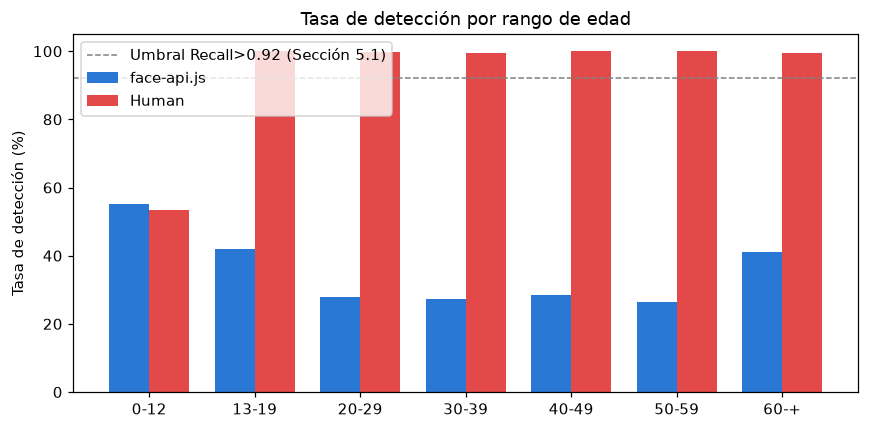

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(BIN_LABELS))
width = 0.38
ax.bar(x - width/2, det["fa_tasa"], width, label="face-api.js", color="#2a78d6")
ax.bar(x + width/2, det["hu_tasa"], width, label="Human", color="#e34948")
ax.axhline(92, color="gray", linestyle="--", linewidth=1, label="Umbral Recall>0.92 (Sección 5.1)")
ax.set_xticks(x)
ax.set_xticklabels(BIN_LABELS)
ax.set_ylabel("Tasa de detección (%)")
ax.set_title("Tasa de detección por rango de edad")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Comparación pareja: MAE, RMSE y sesgo

Solo sobre las filas donde **ambos** motores detectaron la misma imagen —
así ninguno se beneficia de solo medirse contra sus casos más fáciles.


In [7]:
paired = df.dropna(subset=["edad_faceapi", "edad_human"]).copy()
paired["error_faceapi"] = paired["edad_faceapi"] - paired["edad_real"]
paired["error_human"] = paired["edad_human"] - paired["edad_real"]

print(f"Filas pareadas: {len(paired)} de {len(df)} ({len(paired)/len(df)*100:.1f}%)")

def mae(s):
    return s.abs().mean()

def rmse(s):
    return np.sqrt((s ** 2).mean())

resumen_global = pd.DataFrame({
    "MAE": [mae(paired['error_faceapi']), mae(paired['error_human'])],
    "RMSE": [rmse(paired['error_faceapi']), rmse(paired['error_human'])],
    "Sesgo medio": [paired['error_faceapi'].mean(), paired['error_human'].mean()],
}, index=["face-api.js", "Human"])
resumen_global


Filas pareadas: 907 de 3000 (30.2%)


,MAE,RMSE,Sesgo medio
face-api.js,4.96,7.05,-0.27
Human,9.63,14.09,-3.77


In [8]:
por_rango = paired.groupby("rango", observed=True).agg(
    n=("edad_real", "size"),
    mae_faceapi=("error_faceapi", mae),
    mae_human=("error_human", mae),
    sesgo_faceapi=("error_faceapi", "mean"),
    sesgo_human=("error_human", "mean"),
).round(2)
por_rango


,n,mae_faceapi,mae_human,sesgo_faceapi,sesgo_human
rango,,,,,
0-12,130,1.92,7.03,0.36,6.47
13-19,57,3.45,8.77,0.74,7.62
20-29,267,4.37,4.62,0.60,1.70
30-39,152,6.45,5.03,0.43,-2.53
40-49,76,6.87,9.98,-0.07,-8.52
50-59,75,6.49,15.74,-0.55,-12.16
60-+,150,6.01,22.58,-3.43,-21.33


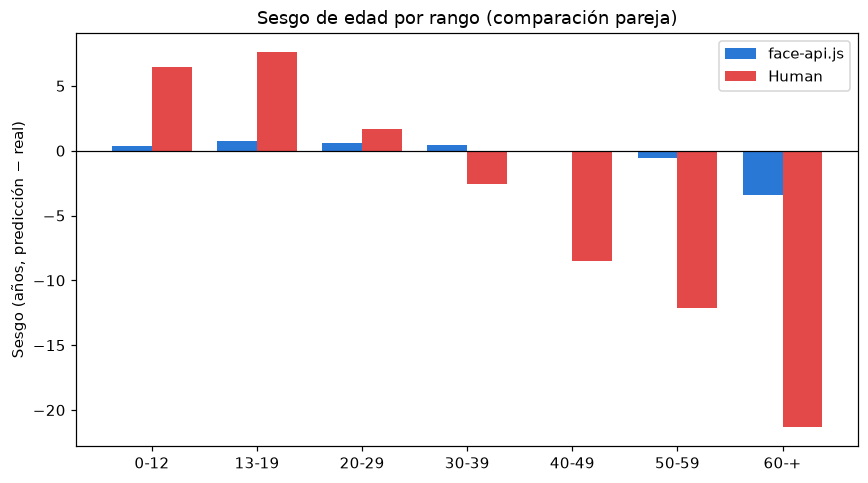

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(por_rango))
width = 0.38
ax.bar(x - width/2, por_rango["sesgo_faceapi"], width, label="face-api.js", color="#2a78d6")
ax.bar(x + width/2, por_rango["sesgo_human"], width, label="Human", color="#e34948")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(por_rango.index)
ax.set_ylabel("Sesgo (años, predicción − real)")
ax.set_title("Sesgo de edad por rango (comparación pareja)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Dispersión: edad predicha vs. edad real

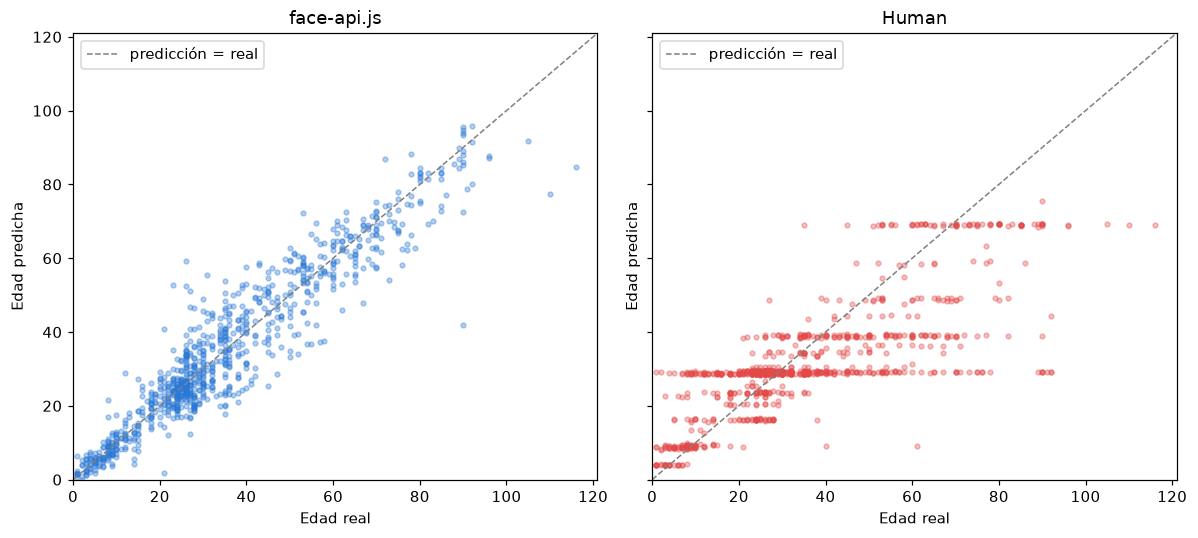

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lims = [0, max(paired['edad_real'].max(), paired['edad_faceapi'].max(), paired['edad_human'].max()) + 5]

for ax, col, label, color in zip(
    axes, ["edad_faceapi", "edad_human"], ["face-api.js", "Human"], ["#2a78d6", "#e34948"]
):
    ax.scatter(paired["edad_real"], paired[col], s=10, alpha=0.35, color=color)
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="predicción = real")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Edad real")
    ax.set_ylabel("Edad predicha")
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()


## 5. Explorador interactivo por rango de edad

Desliza el rango para ver cómo cambian MAE y sesgo en subconjuntos
específicos, sin editar código.


In [11]:
from ipywidgets import interact, IntRangeSlider

edad_min, edad_max = int(df["edad_real"].min()), int(df["edad_real"].max())

@interact(rango_edad=IntRangeSlider(value=[20, 40], min=edad_min, max=edad_max, step=1, description="Edad real"))
def explorar(rango_edad):
    lo, hi = rango_edad
    sub = paired[(paired["edad_real"] >= lo) & (paired["edad_real"] <= hi)]
    if len(sub) == 0:
        print("Sin datos en ese rango.")
        return
    print(f"n = {len(sub)}  (edad real {lo}-{hi})")
    print(f"MAE  face-api: {mae(sub['error_faceapi']):.2f}   Human: {mae(sub['error_human']):.2f}")
    print(f"Sesgo face-api: {sub['error_faceapi'].mean():+.2f}   Human: {sub['error_human'].mean():+.2f}")


interactive(children=(IntRangeSlider(value=(20, 40), description='Edad real', max=116, min=1), Output()), _dom…

## 6. ¿Vale la pena calibrar a Human en vez de descartarlo?

Si Human resulta más robusto que `ageGenderNet` en casos difíciles (lentes,
cubrebocas — pendiente de probar aparte, ver conclusión), su sesgo por edad
es corregible con una regresión simple, igual que ya corrigen `HAPPY_BIAS`
para las emociones. Esto entrena `edad_real ~ edad_predicha` y mide si el MAE
mejora tras la corrección (con split train/test para no hacer trampa).


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

def evaluar_calibracion(col_pred, nombre):
    sub = paired.dropna(subset=[col_pred]).copy()
    X = sub[[col_pred]].values
    y = sub["edad_real"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    mae_sin_calibrar = np.abs(X_test.ravel() - y_test).mean()

    reg = LinearRegression().fit(X_train, y_train)
    pred_calibrada = reg.predict(X_test)
    mae_calibrada = np.abs(pred_calibrada - y_test).mean()

    print(f"{nombre}:")
    print(f"  MAE sin calibrar : {mae_sin_calibrar:.2f} años")
    print(f"  MAE calibrada    : {mae_calibrada:.2f} años  (y = {reg.coef_[0]:.2f}x + {reg.intercept_:.2f})")
    print()
    return reg

reg_faceapi = evaluar_calibracion("edad_faceapi", "face-api.js")
reg_human = evaluar_calibracion("edad_human", "Human")


face-api.js:
  MAE sin calibrar : 4.88 años
  MAE calibrada    : 4.87 años  (y = 0.96x + 1.84)

Human:
  MAE sin calibrar : 9.63 años
  MAE calibrada    : 9.32 años  (y = 1.12x + 0.01)



**Cómo leer esto:** si el MAE calibrado de Human baja mucho y se acerca al de
face-api.js (calibrado o sin calibrar), significa que el problema de Human no
es la información que capta sino el sesgo sistemático — y ese sí es
corregible en producción con una constante/curva, sin tener que descartar el
modelo. Si sigue siendo peor incluso calibrado, es una señal más fuerte de
quedarse con `ageGenderNet`.


## 7. Conclusión (completar tras correr)

- Tasa de detección global: face-api ___%, Human ___%
- MAE pareado: face-api ___, Human ___
- ¿El sesgo de Human se corrige bien con calibración lineal? ___
- **Pendiente fuera de este notebook:** repetir con un subconjunto de fotos
  con lentes/cubrebocas/gorras — UTKFace no distingue accesorios, así que esta
  evaluación NO contesta si Human es más robusto que `ageGenderNet` en el
  escenario que originalmente motivó considerar I5.
- **Decisión:** ___
